In [2]:
import pandas as pd
import re
import math
import cartopy.crs as ccrs
import cartopy
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import statsmodels.api as sm
import geopandas as gpd
import rioxarray
from scipy import stats


In [3]:
ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/1969_2019_all.nc')
ds = ds.resample(time='Q-DEC').mean()
M1_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/M1_range_mslp/1969_2019.nc')

# Store site metadata (site number, site name, catchment number, NZTME, NZTMN)
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

# define alpha and numeric season order
seasons_a = ['Winter','Spring','Summer','Autumn']
seasons_n = [6,9,12,3]

flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)

# load catchment shape data
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")
catchment_data = catchment_data.loc[catchment_data['SITE'].isin(flow_df.columns)]
catchment_data.index = catchment_data['SITE']

In [4]:
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")

catchments_df = catchment_data.loc[catchment_data['SITE'].isin(flow_df.columns)]

subset_meta = metadata_df.loc[[int(s) for s in flow_df.columns]]
subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()

meta_df = gpd.GeoDataFrame(subset_meta, 
                           geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),
                           crs='EPSG:4326')

# load catchment shape data
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")
catchment_data = catchment_data.loc[catchment_data['SITE'].isin(flow_df.columns)]
catchment_data.index = catchment_data['SITE']

In [5]:
def detrend(ts):
    
    for i in range(len(ts)):
        if np.isnan(ts[i]):
            ts[i] = np.nanmean(ts)
    
    X = np.array([[1,i] for i in range(len(ts))])
    y = np.array(ts)
    
    ols = sm.OLS(y, X, missing = 'drop')
    ols_model = ols.fit()

    fit = ols_model.predict()
            
    new_ts = []
    for i in range(len(ts)):
        new_ts.append(ts[i] - (fit[i]-ts[0]))

    return new_ts


In [6]:
'''
Create pressure differential time series of anomalies between Auckland and Christchurch (Z1) 
                and Hobart and the Chatham Islands (M1)
'''

msl_da = M1_ds['msl']

# find cells with coordinates nearest to Auckland and Christchurch

akl_coords = (-36.85, 174.76)
chch_coords = (-43.53, 172.63)
hobart_coords = (-42.88, 147.32)
chatham_coords = (-44, 183.46)

akl_ts_monthly = msl_da.sel(latitude=akl_coords[0],longitude=akl_coords[1],method='nearest')
chch_ts_monthly = msl_da.sel(latitude=chch_coords[0],longitude=chch_coords[1],method='nearest')
hobart_ts_monthly = msl_da.sel(latitude=hobart_coords[0],longitude=hobart_coords[1],method='nearest')
chatham_ts_monthly = msl_da.sel(latitude=chatham_coords[0],longitude=chatham_coords[1],method='nearest')

msl_df = pd.DataFrame.from_dict({'akl':akl_ts_monthly.values.tolist(),
                                 'chch':chch_ts_monthly.values.tolist(),
                                 'hobart':hobart_ts_monthly.values.tolist(),
                                 'chatham':chatham_ts_monthly.values.tolist(),
                                 'date':akl_ts_monthly.time.values.tolist()})

msl_df['Z1'] = msl_df['akl'] - msl_df['chch']
msl_df['M1'] = msl_df['hobart'] - msl_df['chatham']

msl_df.date = pd.to_datetime(msl_df.date)
msl_df.set_index('date', inplace=True)

msl_ts = msl_df[['Z1','M1']]
msl_ts = msl_ts.resample('Q-DEC').mean()
msl_ts.index = [pd.to_datetime(x).replace(day=1) for x in msl_ts.index]


In [7]:
msl_ts

,Z1,M1
1969-03-01,259.705729,-140.627604
1969-06-01,251.791667,791.226562
1969-09-01,319.377604,-480.020833
1969-12-01,324.382812,-257.205729
1970-03-01,99.697917,3.466146
...,...,...
2018-12-01,270.562500,-99.955729
2019-03-01,308.153646,-513.158854
2019-06-01,287.429688,347.721354
2019-09-01,525.622396,513.731771


64602: -0.014441648118668124 -42.5 172.5
79713: -0.09936098688830866 -45.75 167.5
52916: -0.07593285839010455 -41.0 172.5
95101: -0.0837011399883044 -41.25 172.5
65104: -0.0912026348668216 -42.75 172.25
79704: -0.11893803580707553 -45.0 167.75
93203: -0.12849095507491443 -42.0 172.25


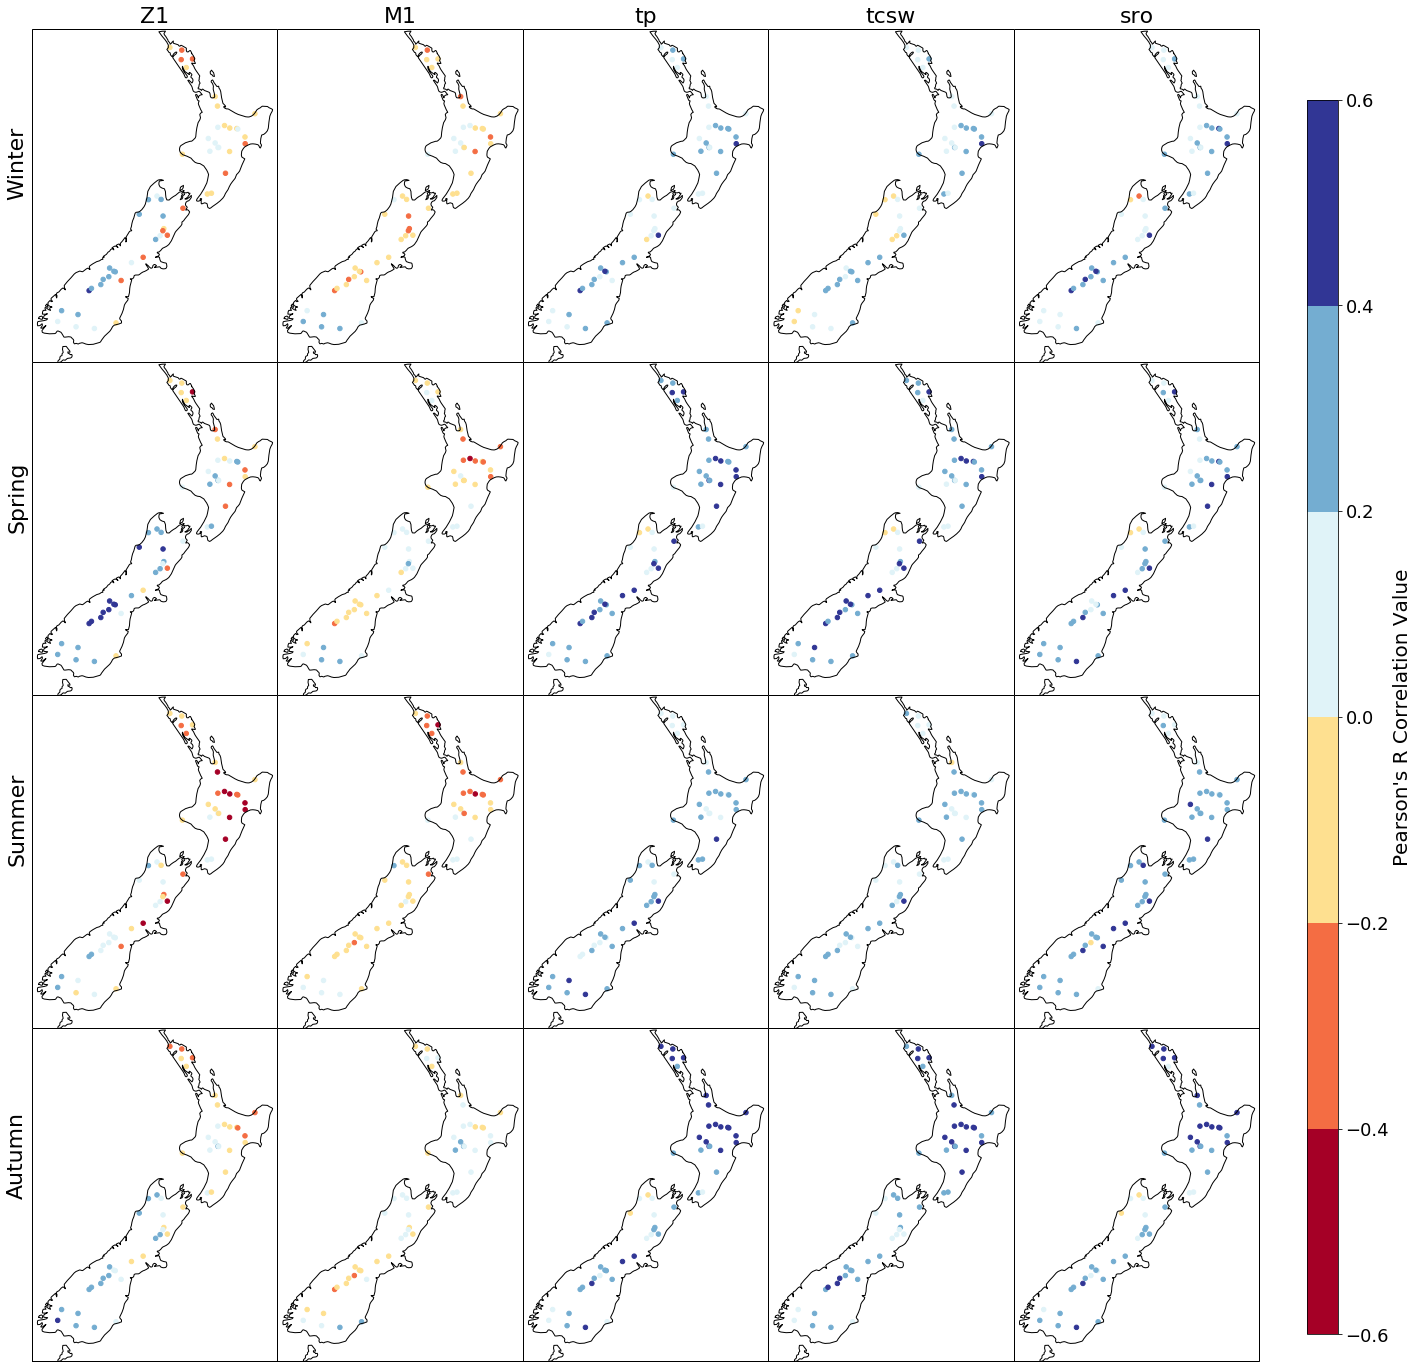

In [6]:
'''
LOCAL DETRENDED correlations between streamflow and ERA5 indices

'''
# Define the CartoPy CRS object.
crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
#catchments_df_ae = catchments_df.to_crs(crs_proj4)
meta_df_ae = meta_df.to_crs(crs_proj4)

fig, axs = plt.subplots(4,5,figsize=(22,24.5),subplot_kw={'projection': crs})

indices = ['Z1','M1','tp','tcsw','sro']

for i,s in enumerate([6,9,12,3]):
    era_season = ds.sel(time=ds.time.dt.month.isin([s]))
    flow_season = flow_df[flow_df.index.month == s]['1969':'2019']

    for j,index in enumerate(indices):
        
        if index in ['Z1','M1']:
            msl_season = msl_ts[index][msl_ts.index.month == s]['1969':'2019']
            
        else:
            index_da = era_season[index]
            
        lons = []
        lats = []
        corr = []
        for site in flow_df:
            
            detrended_flow = detrend(flow_season[site])
            
            if index in ['Z1','M1']:
                (r,p) = stats.pearsonr(detrended_flow,msl_season.values.tolist())
            else:
                gauge_coords = [float(metadata_df.loc[int(site)]['centroid_lat']),float(metadata_df.loc[int(site)]['centroid_lon'])]

                cell_ts = index_da.sel(latitude=gauge_coords[0],longitude=gauge_coords[1],method='nearest')
                                       
                (r,p) = stats.pearsonr(detrended_flow,cell_ts.values.tolist())
                
            lon = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0]
            lat = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1]
            
            lats.append(lat)
            lons.append(lon)
            corr.append(r)
            
        axs[i][j].coastlines(resolution='50m', color='black',linewidth=1,zorder = 1)
        axs[i][j].set_xlim([18500000,19900000])
        axs[i][j].set_ylim([-5950000,-4050000])

        im = axs[i][j].scatter(lons,lats,marker='.',s=80,c=corr,cmap=plt.cm.get_cmap('RdYlBu', 6),vmin=-0.6,vmax=0.6)

        if j == 0:
            axs[i][j].text(-0.1,0.5,{3:'Autumn',6:'Winter',9:'Spring',12:'Summer'}[s],
                           rotation='vertical',transform=axs[i][j].transAxes,
                           fontsize=22)
            
        if i == 0:
            axs[i][j].set_title(index, fontsize=22)
            

cax = fig.add_axes([.93,0.14,.02,.7])
cbar = fig.colorbar(im, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=18)
cbar.set_label('Pearson\'s R Correlation Value',size=20)

plt.subplots_adjust(wspace=0, hspace=0)

#plt.savefig("Figure8.png",dpi=300,bbox_inches='tight')


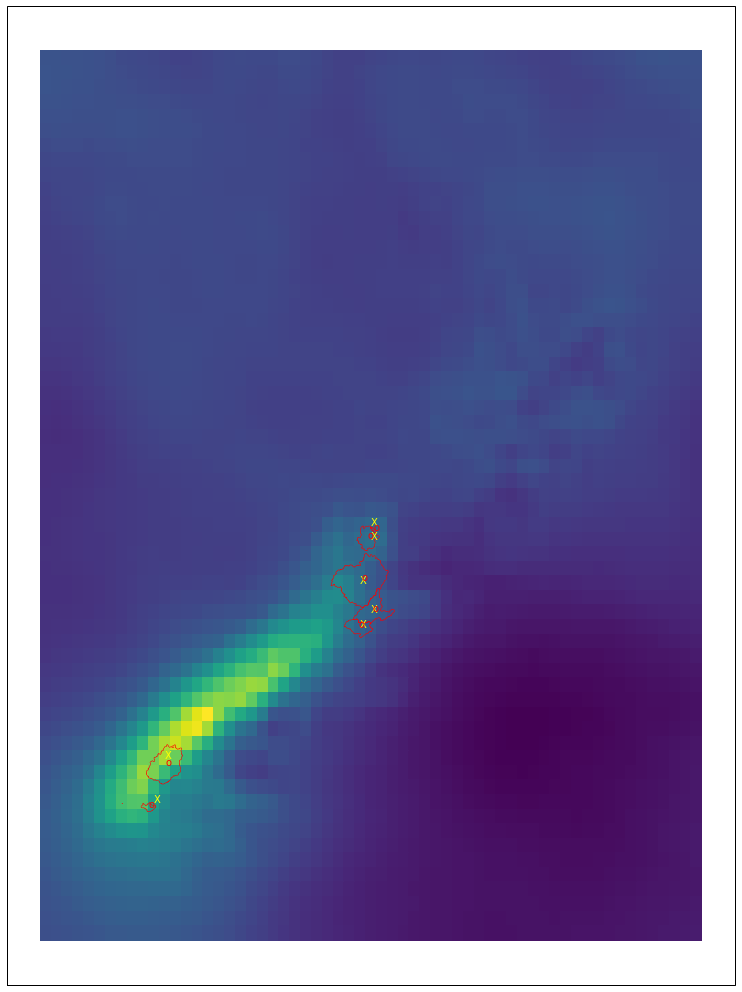

In [18]:
'''
plot nearest cell locations / catchments / centroids
'''

# Define the CartoPy CRS object.
crs = ccrs.Mercator()
fig, ax = plt.subplots(figsize=(22,18),subplot_kw={'projection': crs})

indices = ['tcsw']#'tp','tcsw','sro']

for i,s in enumerate([6]):#,9,12,3]):
    era_season = ds.sel(time=ds.time.dt.month.isin([s]))

    for j,index in enumerate(indices):

        index_da = era_season[index]
        index_da.mean('time').plot.pcolormesh(ax=ax, transform=crs,add_colorbar=False)
        
        for site in ['64602', '79713', '52916', '95101', '65104', '79704', '93203', ]:

            if site == '4901':
                continue
                
            gauge_coords = [float(metadata_df.loc[int(site)]['centroid_lat']),float(metadata_df.loc[int(site)]['centroid_lon'])]

            cell = index_da.sel(latitude=gauge_coords[0],longitude=gauge_coords[1],method='nearest')
            
            cell_lat = cell.latitude.values.tolist()
            cell_lon = cell.longitude.values.tolist()
            
            catchment_data.loc[[float(site)]].plot(ax=ax,color='',edgecolor='red',linewidth=0.4,alpha=1)
            plt.text(cell_lon,cell_lat,"X",color='yellow')
            plt.text(gauge_coords[1],gauge_coords[0],"o",color="red")


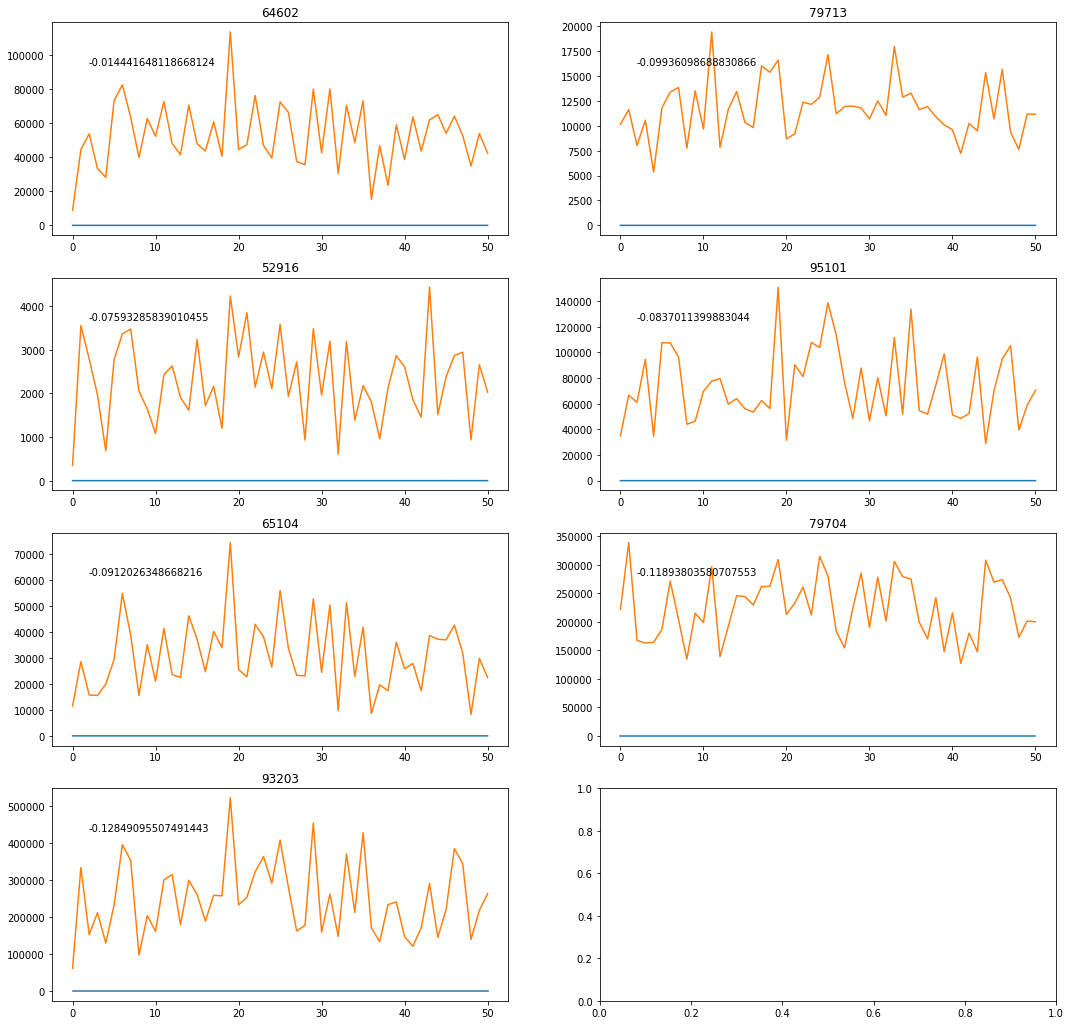

In [17]:
'''
plot time series of obs flow and nearest cell index values for select catchments
'''


fig, ax = plt.subplots(4,2,figsize=(18,18))
axs = ax.flatten()

index = 'tcsw'#'tp','tcsw','sro']

for s in [6]:#,9,12,3]):
    era_season = ds.sel(time=ds.time.dt.month.isin([s]))
    flow_season = flow_df[flow_df.index.month == s]['1969':'2019']
    index_da = era_season[index]
    
    for i,site in enumerate(['64602', '79713', '52916', '95101', '65104', '79704', '93203', ]):
        
        detrended_flow = detrend(flow_season[site])
            
        gauge_coords = [float(metadata_df.loc[int(site)]['centroid_lat']),float(metadata_df.loc[int(site)]['centroid_lon'])]

        cell_ts = index_da.sel(latitude=gauge_coords[0],longitude=gauge_coords[1],method='nearest')
                                       
        (r,p) = stats.pearsonr(detrended_flow,cell_ts.values.tolist())

        axs[i].plot(cell_ts)
        axs[i].plot(detrended_flow)

        axs[i].text(0.08,0.8,str(r), transform=axs[i].transAxes)
        axs[i].set_title(site)
        
        


In [ ]:
'''
heatmap of correlations for single flow record
'''

def plot_heatmap(site,index):
    fig, axs = plt.subplots(2,2,figsize=(16,16),subplot_kw={'projection': ccrs.PlateCarree()})
    axs = axs.flatten()
    
    for i,season in enumerate(seasons_n):
        flow_site = flow_df[flow_df.index.month == season]['1970':][str(site)].to_frame()

        tp = ds[index].resample(time='Q-DEC').mean()
        tp = tp[tp.time.dt.month == season].loc['1970':]

        lats = tp.latitude
        lons = tp.longitude

        plot_lons = []
        plot_lats = []
        plot_rs = []

        for lat in lats:
            for lon in lons:
                ts_cell = tp.loc[dict(longitude=lon,latitude=lat)]

                coord = str(lat.values.tolist()) + ' ' + str(lon.values.tolist())

                cell_df = pd.DataFrame.from_dict({coord:ts_cell.values.tolist(),'date':ts_cell.time.values.tolist()})
                cell_df.date = pd.to_datetime(cell_df.date)
                cell_df.set_index('date', inplace=True)
                cell_df.index = [pd.to_datetime(x).replace(day=1) for x in cell_df.index]

                r = flow_site.join(cell_df).corr()[str(site)][coord]

                plot_lons.append(float(coord.split(' ')[1]))
                plot_lats.append(float(coord.split(' ')[0]))
                plot_rs.append(r)

        im = axs[i].scatter(plot_lons,plot_lats,marker='s',s=80,c=plot_rs,vmin=-0.6,vmax=0.6,cmap=plt.cm.get_cmap('RdYlBu', 6))#'bwr_r')
        axs[i].scatter(metadata_df.loc[site]['gauge_lon'],metadata_df.loc[site]['gauge_lat'],marker='*',s=140,c='r')

        axs[i].coastlines(resolution='50m', color='black', linewidth=1)
        axs[i].set_xlim([164,180])
        
        axs[i].text(.17, .89, seasons_a[i], fontsize= 16, horizontalalignment="center", verticalalignment="center", transform=axs[i].transAxes)


        fig.colorbar(im, orientation='vertical')
    #plt.subplots_adjust(wspace=0, hspace=0)


In [ ]:
def find_5_years(da):
    

In [ ]:
flow_site = flow_df[flow_df.index.month == 3]['1970':][str(1316)].to_frame()

[val.year for val in flow_site.nlargest(3,'1316').index]

In [ ]:
'''
heatmap of correlations for single flow record
'''

def plot_5_extremes_heatmaps(site,index,extreme):
    fig, axs = plt.subplots(4,5,figsize=(14,14),subplot_kw={'projection': ccrs.PlateCarree()})
    #axs = axs.flatten()
    
    for i,season in enumerate(seasons_n):
        flow_site = flow_df[flow_df.index.month == season]['1970':][str(site)].to_frame()

        era5 = ds[index].resample(time='Q-DEC').mean()
        era5 = era5[era5.time.dt.month == season].loc['1970':]

        lats = era5.latitude
        lons = era5.longitude
        
        if extreme is 'highest':
            target_years = [val.year for val in flow_site.nlargest(5,str(site)).index]
            
        elif extreme is 'lowest':
            target_years = [val.year for val in flow_site.nsmallest(5,str(site)).index]
        
        for j,year in enumerate(target_years):
            
            era5_year = era5[era5.time.dt.year == year]
            
            era5_year.plot(ax=axs[i,j],add_colorbar=False,transform=ccrs.PlateCarree(),cmap=plt.cm.get_cmap('RdYlBu', 8))

            axs[i,j].coastlines(resolution='50m', color='black', linewidth=1)
            axs[i,j].set_xlim([164,180])
            
            axs[i,j].scatter(metadata_df.loc[site]['gauge_lon'],metadata_df.loc[site]['gauge_lat'],marker='*',s=140,c='r')

    plt.subplots_adjust(wspace=0, hspace=0)


In [ ]:
plot_5_extremes_heatmaps(29224,'msl','lowest')

In [ ]:
plot_5_extremes_heatmaps(29224,'msl','highest')

In [ ]:
plot_heatmap(71135,'msl')

In [ ]:
plot_heatmap(68001,'msl')

In [ ]:
plot_heatmap(1316,'msl')

In [ ]:
plot_heatmap(29224,'msl')

In [ ]:
plot_heatmap(79713,'msl')

In [ ]:
plot_heatmap(57009,'msl')

In [ ]:
plot_heatmap(15408,'msl')